In [ ]:
from google.colab import drive
import os, glob, zipfile
drive.mount("/content/drive")


DRIVE_PATH = "/content/drive/MyDrive/Dataset"

if not os.path.exists(DRIVE_PATH):

    found = sorted({p for depth in range(4)
                    for p in glob.glob("/content/drive/MyDrive" + "/*" * depth + "/*[dD][iI][vV]2[kK]*")})
    print("Not found:", DRIVE_PATH)
    print("Things on your Drive whose name contains 'div2k':")
    for p in found: print("   ", p)
    raise FileNotFoundError("Set DRIVE_PATH to one of the paths above.")

if DRIVE_PATH.lower().endswith(".zip"):
    DATA_ROOT = "/content/div2k"
    if not os.path.isdir(DATA_ROOT):
        print("Unzipping to", DATA_ROOT, "...")
        with zipfile.ZipFile(DRIVE_PATH) as zf:
            zf.extractall(DATA_ROOT)
else:
    DATA_ROOT = DRIVE_PATH
print("DATA_ROOT =", DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT = /content/drive/MyDrive/Dataset


In [ ]:
import os, glob, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


SCALE = 2                  # upscaling factor (×2). Try 4 later: harder task.
HR_PATCH = 96              # training patches are 96×96 HR  →  48×48 LR
N_TRAIN_IMAGES = 300       # how many of the 800 training images to use (more = better but slower)
N_VAL_IMAGES = 50          # taken from the training folder, never used for training
PATCHES_PER_IMAGE = 16     # random patches cut from each training image
N_TEST_IMAGES = 50         # from the official DIV2K validation folder = our TEST set
TEST_CROP = 256            # test on the central 256×256 HR crop of each image (faster)
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4


print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
### Cell 3 — Tìm thư mục ảnh HR, chia train / validation / test
def list_images(folder):
    exts = ("*.png", "*.jpg", "*.jpeg")
    return sorted(f for e in exts for f in glob.glob(os.path.join(folder, e)))

# every folder that directly contains images, with its number of images
folders = {}
for root, dirs, files in os.walk(DATA_ROOT):
    n = sum(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in files)
    if n > 0:
        folders[root] = n
for f, n in sorted(folders.items()):
    print(f"{n:5d} images  {f}")

import re
def is_hr(path):   # a folder name such as DIV2K_train_HR, HR, train_hr ... and nothing that looks like LR
    parts = [p.upper() for p in path.split(os.sep)]
    return any(re.search(r"(^|[_\-\s])HR($|[_\-\s])", p) for p in parts) and not any("LR" in p for p in parts)

hr_folders = [f for f in folders if is_hr(f)]
train_dirs = sorted(f for f in hr_folders if "TRAIN" in f.upper())
valid_dirs = sorted(f for f in hr_folders if "VALID" in f.upper() or "VAL" in f.upper().split(os.sep)[-1])
assert train_dirs, "No training HR folder found - check DATA_ROOT and the folder list above."

train_files = list_images(train_dirs[0])
test_files = list_images(valid_dirs[0]) if valid_dirs else []
if not test_files:                        # no official validation folder: keep the last 100 images apart
    train_files, test_files = train_files[:-100], train_files[-100:]

random.shuffle(train_files)
val_files = train_files[:N_VAL_IMAGES]                               # validation: from the training folder
train_files = train_files[N_VAL_IMAGES:N_VAL_IMAGES + N_TRAIN_IMAGES]
test_files = test_files[:N_TEST_IMAGES]
print(f"\ntrain images: {len(train_files)} | validation images: {len(val_files)} | test images: {len(test_files)}")
print("train folder:", train_dirs[0]); print("test folder: ", valid_dirs[0] if valid_dirs else "(split from train)")

  800 images  /content/drive/MyDrive/Dataset/DIV2K_train_HR
  800 images  /content/drive/MyDrive/Dataset/DIV2K_train_LR_bicubic/X2
  800 images  /content/drive/MyDrive/Dataset/DIV2K_train_LR_bicubic_X4/X4
  100 images  /content/drive/MyDrive/Dataset/DIV2K_valid_HR
  100 images  /content/drive/MyDrive/Dataset/DIV2K_valid_LR_bicubic/X2
  100 images  /content/drive/MyDrive/Dataset/DIV2K_valid_LR_bicubic_X4/X4

train images: 300 | validation images: 50 | test images: 50
train folder: /content/drive/MyDrive/Dataset/DIV2K_train_HR
test folder:  /content/drive/MyDrive/Dataset/DIV2K_valid_HR


In [ ]:
### Cell 4 — Đọc ảnh và cắt patch
def load_rgb(path):
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0

def random_patches(img, n, size):
    h, w, _ = img.shape
    out = []
    for _ in range(n):
        y, x = np.random.randint(0, h - size + 1), np.random.randint(0, w - size + 1)
        out.append(img[y:y + size, x:x + size])
    return out

def center_crop(img, size):
    h, w, _ = img.shape
    y, x = (h - size) // 2, (w - size) // 2
    return img[y:y + size, x:x + size]

t0 = time.time()
train_hr = np.stack([p for f in train_files for p in random_patches(load_rgb(f), PATCHES_PER_IMAGE, HR_PATCH)])
val_hr = np.stack([p for f in val_files for p in random_patches(load_rgb(f), PATCHES_PER_IMAGE, HR_PATCH)])
test_hr = np.stack([center_crop(load_rgb(f), TEST_CROP) for f in test_files])
print(f"train patches {train_hr.shape} | val patches {val_hr.shape} | test images {test_hr.shape} | {time.time()-t0:.0f}s")

train patches (4800, 96, 96, 3) | val patches (800, 96, 96, 3) | test images (50, 256, 256, 3) | 95s


In [ ]:
### Cell 5 — Hàm tạo ảnh LR: blur -> giảm kích thước -> nhiễu -> JPEG
def gaussian_kernel(sigma, size=9):
    ax = tf.range(size, dtype=tf.float32) - (size - 1) / 2
    g = tf.exp(-(ax ** 2) / (2.0 * sigma ** 2))
    k = tf.tensordot(g, g, axes=0)
    k = k / tf.reduce_sum(k)
    return tf.tile(k[:, :, None, None], [1, 1, 3, 1])          # same kernel for R, G, B

def blur(img, sigma, size=9):
    # img: [H, W, 3]. Reflect padding, then a depthwise convolution (one kernel per channel).
    p = size // 2
    x = tf.pad(img[None], [[0, 0], [p, p], [p, p], [0, 0]], mode="REFLECT")
    return tf.nn.depthwise_conv2d(x, gaussian_kernel(sigma, size), strides=[1, 1, 1, 1], padding="VALID")[0]

def degrade(hr, blur_sigma=0.0, noise_sigma=0.0, jpeg_quality=None):
    # Returns (model input = bicubic-upscaled LR, LR). All values in [0, 1].
    h, w = tf.shape(hr)[0], tf.shape(hr)[1]
    x = hr
    if blur_sigma > 0:
        x = blur(x, blur_sigma)
    lr = tf.image.resize(x, [h // SCALE, w // SCALE], method="bicubic", antialias=True)
    lr = tf.clip_by_value(lr, 0.0, 1.0)
    if noise_sigma > 0:
        lr = tf.clip_by_value(lr + tf.random.normal(tf.shape(lr), stddev=noise_sigma), 0.0, 1.0)
    if jpeg_quality is not None:
        lr = tf.image.adjust_jpeg_quality(lr, jpeg_quality)
    up = tf.clip_by_value(tf.image.resize(lr, [h, w], method="bicubic"), 0.0, 1.0)
    return up, lr

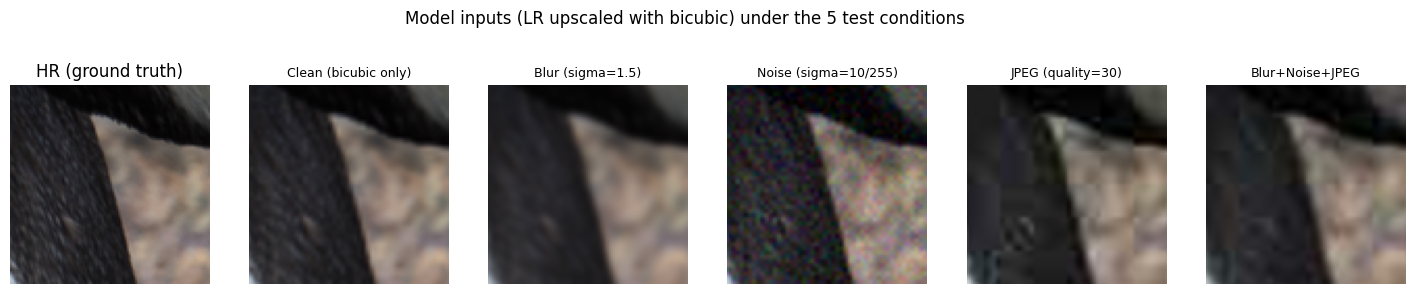

In [ ]:
### Cell 6 — 5 điều kiện test (1 sạch + 4 degradation lạ)
TEST_CONDITIONS = {
    "Clean (bicubic only)": dict(blur_sigma=0.0, noise_sigma=0.0,      jpeg_quality=None),
    "Blur (sigma=1.5)":     dict(blur_sigma=1.5, noise_sigma=0.0,      jpeg_quality=None),
    "Noise (sigma=10/255)": dict(blur_sigma=0.0, noise_sigma=10 / 255, jpeg_quality=None),
    "JPEG (quality=30)":    dict(blur_sigma=0.0, noise_sigma=0.0,      jpeg_quality=30),
    "Blur+Noise+JPEG":      dict(blur_sigma=1.0, noise_sigma=5 / 255,  jpeg_quality=50),
}

# Build every degraded test input ONCE (fixed seed) so that all models are compared on identical images.
tf.random.set_seed(SEED)
test_inputs = {name: np.stack([degrade(tf.constant(img), **cfg)[0].numpy() for img in test_hr])
               for name, cfg in TEST_CONDITIONS.items()}

# Look at one test image under each condition (zoomed centre, 96×96 pixels)
fig, axes = plt.subplots(1, len(TEST_CONDITIONS) + 1, figsize=(18, 3.6))
z = slice(TEST_CROP // 2 - 48, TEST_CROP // 2 + 48)
axes[0].imshow(test_hr[0][z, z]); axes[0].set_title("HR (ground truth)")
for ax, (name, imgs) in zip(axes[1:], test_inputs.items()):
    ax.imshow(imgs[0][z, z]); ax.set_title(name, fontsize=9)
for ax in axes: ax.axis("off")
plt.suptitle("Model inputs (LR upscaled with bicubic) under the 5 test conditions"); plt.show()

In [ ]:
### Cell 7 — Metric PSNR, SSIM và baseline bicubic
def evaluate(pred, target):
    pred = tf.clip_by_value(tf.convert_to_tensor(pred), 0.0, 1.0)
    target = tf.convert_to_tensor(target)
    return (float(tf.reduce_mean(tf.image.psnr(pred, target, max_val=1.0))),
            float(tf.reduce_mean(tf.image.ssim(pred, target, max_val=1.0))))

results = []   # rows: model, condition, PSNR, SSIM

# Baseline = bicubic interpolation (the model input itself, no learning)
for name, imgs in test_inputs.items():
    psnr, ssim = evaluate(imgs, test_hr)
    results.append(dict(model="Bicubic", condition=name, PSNR=psnr, SSIM=ssim))
pd.DataFrame(results).round(3)

,model,condition,PSNR,SSIM
0,Bicubic,Clean (bicubic only),29.753,0.865
1,Bicubic,Blur (sigma=1.5),26.297,0.739
2,Bicubic,Noise (sigma=10/255),26.163,0.663
3,Bicubic,JPEG (quality=30),25.752,0.711
4,Bicubic,Blur+Noise+JPEG,25.618,0.700


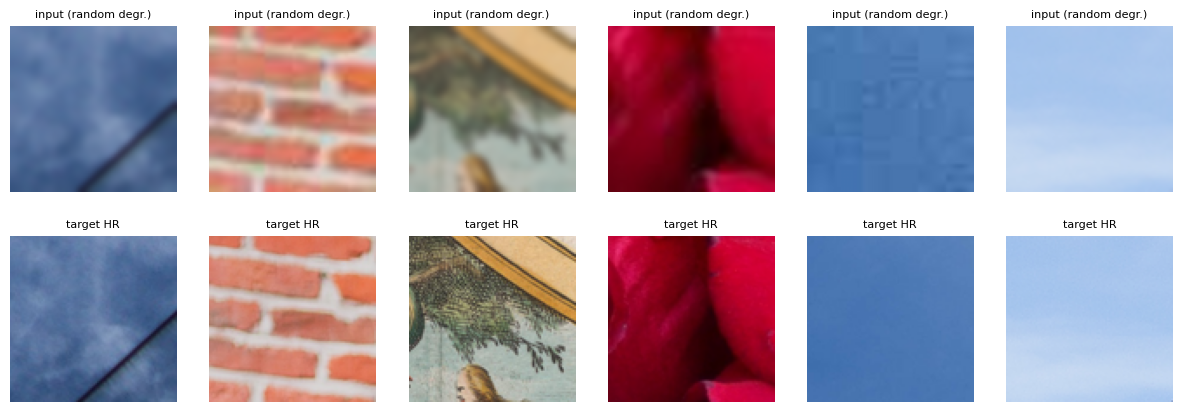

In [ ]:
### Cell 8 — Pipeline dữ liệu train (sạch cho A, B; degradation ngẫu nhiên cho C)
def random_flip(hr):
    return tf.image.random_flip_left_right(hr)

def make_pair_clean(hr):
    hr = random_flip(hr)
    up, _ = degrade(hr)
    return up, hr

def make_pair_random(hr):
    hr = random_flip(hr)
    h, w = HR_PATCH, HR_PATCH
    x = hr
    # (1) blur with probability 0.5, sigma in [0.2, 2.0]
    x = tf.cond(tf.random.uniform([]) < 0.5, lambda: blur(x, tf.random.uniform([], 0.2, 2.0)), lambda: x)
    # (2) bicubic downscale
    lr = tf.clip_by_value(tf.image.resize(x, [h // SCALE, w // SCALE], method="bicubic", antialias=True), 0.0, 1.0)
    # (3) noise with probability 0.5, sigma in [1, 15] / 255
    sigma = tf.random.uniform([], 1.0, 15.0) / 255.0
    lr = tf.cond(tf.random.uniform([]) < 0.5,
                 lambda: tf.clip_by_value(lr + tf.random.normal(tf.shape(lr), stddev=sigma), 0.0, 1.0), lambda: lr)
    # (4) JPEG with probability 0.5, quality in [30, 95]
    lr = tf.cond(tf.random.uniform([]) < 0.5, lambda: tf.image.random_jpeg_quality(lr, 30, 95), lambda: lr)
    lr = tf.reshape(lr, [h // SCALE, w // SCALE, 3])
    up = tf.clip_by_value(tf.image.resize(lr, [h, w], method="bicubic"), 0.0, 1.0)
    return up, hr

def make_dataset(hr_patches, pair_fn, shuffle):
    ds = tf.data.Dataset.from_tensor_slices(hr_patches)
    if shuffle:
        ds = ds.shuffle(len(hr_patches), seed=SEED)
    return ds.map(pair_fn, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_clean = make_dataset(train_hr, make_pair_clean, shuffle=True)
val_clean = make_dataset(val_hr, make_pair_clean, shuffle=False)
train_random = make_dataset(train_hr, make_pair_random, shuffle=True)
val_random = make_dataset(val_hr, make_pair_random, shuffle=False)

# Show a few augmented training inputs for Model C
xb, yb = next(iter(train_random))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(xb[i]); axes[0, i].set_title("input (random degr.)", fontsize=8)
    axes[1, i].imshow(yb[i]); axes[1, i].set_title("target HR", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.show()

In [ ]:
### Cell 9 — Model A: SRCNN (3 lớp conv)
def build_srcnn(predict_residual=True):
    inp = keras.Input(shape=(None, None, 3))
    x = layers.Conv2D(64, 9, padding="same", activation="relu")(inp)
    x = layers.Conv2D(32, 5, padding="same", activation="relu")(x)
    if predict_residual:
        details = layers.Conv2D(3, 5, padding="same", kernel_initializer="zeros")(x)
        out = layers.Add()([inp, details])          # output = bicubic input + predicted details
    else:
        out = layers.Conv2D(3, 5, padding="same")(x)  # original SRCNN: predicts the whole image
    return keras.Model(inp, out, name="SRCNN")

srcnn = build_srcnn()
srcnn.summary()
print("Layer 1 by hand:", 64 * (9 * 9 * 3 + 1), "| layer 2:", 32 * (5 * 5 * 64 + 1), "| layer 3:", 3 * (5 * 5 * 32 + 1))

Model: "SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │     15,616 │ input_layer[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     51,232 │ conv2d[0][0]      │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      2,403 │ conv2d_1[0][0]    │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ input_layer[0][0… │
│                     │ None, 3)          │            │ conv2d_2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,251 (270.51 KB)

 Trainable params: 69,251 (270.51 KB)

 Non-trainable params: 0 (0.00 B)

Layer 1 by hand: 15616 | layer 2: 51232 | layer 3: 2403


In [ ]:
### Cell 10 — Model B: CNN sâu với residual block (kiểu ResNet)
def residual_block(x, filters=64):
    skip = x
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    return layers.Add()([x, skip])                  # F(x) + x

def build_residual_sr(n_blocks=8, filters=64, name="ResidualSR"):
    inp = keras.Input(shape=(None, None, 3))
    x = first = layers.Conv2D(filters, 3, padding="same")(inp)
    for _ in range(n_blocks):
        x = residual_block(x, filters)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Add()([x, first])                    # skip over all the blocks
    # last layer starts at zero -> at the start of training the model outputs exactly the bicubic input,
    # and training can only add useful details on top of it
    details = layers.Conv2D(3, 3, padding="same", kernel_initializer="zeros")(x)
    out = layers.Add()([inp, details])              # global residual: input + predicted details
    return keras.Model(inp, out, name=name)

build_residual_sr().summary()

Model: "ResidualSR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      1,792 │ input_layer_1[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_3[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_4[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None,      │          0 │ conv2d_5[0][0],   │
│                     │ None, 64)         │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │     36,928 │ add_1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_6[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None,      │          0 │ conv2d_7[0][0],   │
│                     │ None, 64)         │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │     36,928 │ add_2[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_8[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None,      │          0 │ conv2d_9[0][0],   │
│                     │ None, 64)         │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, None,      │     36,928 │ add_3[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_10[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, None,      │          0 │ conv2d_11[0][0],  │
│                     │ None, 64)         │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, None,      │     36,928 │ add_4[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_12[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, None,      │          0 │ conv2d_13[0][0],

 Total params: 631,299 (2.41 MB)

 Trainable params: 631,299 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Cell 11 — Hàm train (MSE loss + Adam) và train Model A
def psnr_metric(y_true, y_pred):
    # PSNR = 10·log10(1 / MSE). The tiny floor avoids "inf" on perfectly flat patches (MSE = 0).
    mse = tf.reduce_mean(tf.square(tf.clip_by_value(y_pred, 0.0, 1.0) - y_true), axis=[1, 2, 3])
    return 10.0 * tf.math.log(1.0 / tf.maximum(mse, 1e-10)) / tf.math.log(10.0)

def train(model, train_ds, val_ds):
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="mse", metrics=[psnr_metric])
    ckpt = f"{model.name}.weights.h5"
    cb = [keras.callbacks.ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True, save_weights_only=True)]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=2)
    model.load_weights(ckpt)
    print(f"{model.name}: trained in {(time.time() - t0) / 60:.1f} min")
    return hist.history

histories = {}
model_A = build_srcnn()
histories["A: SRCNN (clean)"] = train(model_A, train_clean, val_clean)

Epoch 1/10
300/300 - 15s - 51ms/step - loss: 0.0013 - psnr_metric: 35.5231 - val_loss: 0.0013 - val_psnr_metric: 34.8499
Epoch 2/10
300/300 - 7s - 25ms/step - loss: 0.0012 - psnr_metric: 36.0879 - val_loss: 0.0013 - val_psnr_metric: 34.9562
Epoch 3/10
300/300 - 7s - 22ms/step - loss: 0.0011 - psnr_metric: 36.1137 - val_loss: 0.0012 - val_psnr_metric: 34.7762
Epoch 4/10
300/300 - 7s - 25ms/step - loss: 0.0011 - psnr_metric: 36.2128 - val_loss: 0.0012 - val_psnr_metric: 34.9235
Epoch 5/10
300/300 - 7s - 23ms/step - loss: 0.0011 - psnr_metric: 36.2353 - val_loss: 0.0012 - val_psnr_metric: 34.8683
Epoch 6/10
300/300 - 7s - 24ms/step - loss: 0.0011 - psnr_metric: 36.3156 - val_loss: 0.0012 - val_psnr_metric: 35.0291
Epoch 7/10
300/300 - 7s - 22ms/step - loss: 0.0011 - psnr_metric: 36.2684 - val_loss: 0.0012 - val_psnr_metric: 34.9012
Epoch 8/10
300/300 - 8s - 25ms/step - loss: 0.0011 - psnr_metric: 36.2100 - val_loss: 0.0012 - val_psnr_metric: 34.9369
Epoch 9/10
300/300 - 7s - 22ms/step - l

In [ ]:
### Cell 12 — Train Model B
model_B = build_residual_sr(name="ResidualSR_clean")
histories["B: Residual (clean)"] = train(model_B, train_clean, val_clean)

Epoch 1/10
300/300 - 74s - 246ms/step - loss: 0.0012 - psnr_metric: 35.8809 - val_loss: 0.0012 - val_psnr_metric: 34.9747
Epoch 2/10
300/300 - 62s - 207ms/step - loss: 0.0011 - psnr_metric: 36.3573 - val_loss: 0.0011 - val_psnr_metric: 35.1159
Epoch 3/10
300/300 - 62s - 208ms/step - loss: 0.0010 - psnr_metric: 36.5489 - val_loss: 0.0011 - val_psnr_metric: 35.3621
Epoch 4/10
300/300 - 63s - 210ms/step - loss: 9.8492e-04 - psnr_metric: 36.7071 - val_loss: 0.0011 - val_psnr_metric: 35.3538
Epoch 5/10
300/300 - 63s - 209ms/step - loss: 9.6683e-04 - psnr_metric: 36.8159 - val_loss: 0.0011 - val_psnr_metric: 35.5987
Epoch 6/10
300/300 - 63s - 209ms/step - loss: 9.5717e-04 - psnr_metric: 36.8820 - val_loss: 0.0011 - val_psnr_metric: 35.6284
Epoch 7/10
300/300 - 62s - 208ms/step - loss: 9.5105e-04 - psnr_metric: 36.9317 - val_loss: 0.0011 - val_psnr_metric: 35.6529
Epoch 8/10
300/300 - 62s - 208ms/step - loss: 9.3720e-04 - psnr_metric: 37.0162 - val_loss: 0.0011 - val_psnr_metric: 35.5704
Epoc

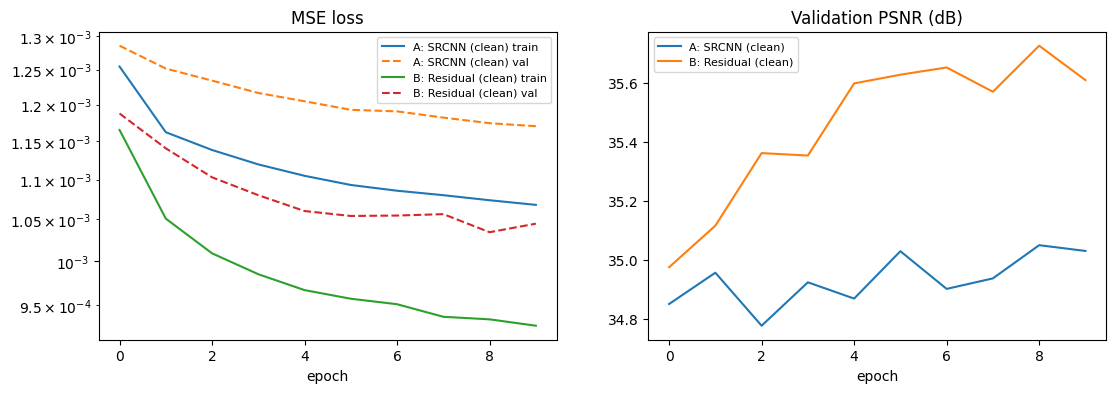

In [ ]:
### Cell 13 — Đồ thị loss và PSNR theo epoch
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in histories.items():
    axes[0].plot(h["loss"], label=f"{name} train"); axes[0].plot(h["val_loss"], "--", label=f"{name} val")
    axes[1].plot(h["val_psnr_metric"], label=name)
axes[0].set_title("MSE loss"); axes[0].set_xlabel("epoch"); axes[0].set_yscale("log"); axes[0].legend(fontsize=8)
axes[1].set_title("Validation PSNR (dB)"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=8)
plt.show()

In [ ]:
### Cell 14 — Test A và B trên cả 5 điều kiện
def test_model(model, label):
    for name, imgs in test_inputs.items():
        pred = model.predict(imgs, batch_size=4, verbose=0)
        psnr, ssim = evaluate(pred, test_hr)
        results.append(dict(model=label, condition=name, PSNR=psnr, SSIM=ssim))

test_model(model_A, "A: SRCNN (clean)")
test_model(model_B, "B: Residual (clean)")

def show_table():
    df = pd.DataFrame(results)
    return df.pivot_table(index="condition", columns="model", values="PSNR", sort=False).round(2)
show_table()

model,Bicubic,A: SRCNN (clean),B: Residual (clean)
condition,,,
Clean (bicubic only),29.75,31.37,32.21
Blur (sigma=1.5),26.30,26.73,26.73
Noise (sigma=10/255),26.16,25.62,25.36
JPEG (quality=30),25.75,25.62,25.57
Blur+Noise+JPEG,25.62,25.74,25.70


In [ ]:
### Cell 15 — Model C: giống B nhưng train với degradation ngẫu nhiên, rồi test
model_C = build_residual_sr(name="ResidualSR_random")
histories["C: Residual (random degr.)"] = train(model_C, train_random, val_random)
test_model(model_C, "C: Residual (random degr.)")
table_psnr = show_table()
table_ssim = pd.DataFrame(results).pivot_table(index="condition", columns="model", values="SSIM", sort=False).round(4)
display(table_psnr); display(table_ssim)
pd.DataFrame(results).to_csv("results_topic17.csv", index=False)

Epoch 1/10
300/300 - 72s - 239ms/step - loss: 0.0024 - psnr_metric: 30.3781 - val_loss: 0.0024 - val_psnr_metric: 30.0423
Epoch 2/10
300/300 - 80s - 266ms/step - loss: 0.0022 - psnr_metric: 30.7165 - val_loss: 0.0024 - val_psnr_metric: 30.2938
Epoch 3/10
300/300 - 63s - 211ms/step - loss: 0.0022 - psnr_metric: 30.8799 - val_loss: 0.0023 - val_psnr_metric: 30.4001
Epoch 4/10
300/300 - 64s - 213ms/step - loss: 0.0022 - psnr_metric: 30.9286 - val_loss: 0.0023 - val_psnr_metric: 30.4579
Epoch 5/10
300/300 - 63s - 211ms/step - loss: 0.0021 - psnr_metric: 30.9918 - val_loss: 0.0023 - val_psnr_metric: 30.4429
Epoch 6/10
300/300 - 63s - 211ms/step - loss: 0.0021 - psnr_metric: 31.0972 - val_loss: 0.0023 - val_psnr_metric: 30.4836
Epoch 7/10
300/300 - 63s - 212ms/step - loss: 0.0021 - psnr_metric: 31.1120 - val_loss: 0.0023 - val_psnr_metric: 30.5159
Epoch 8/10
300/300 - 63s - 212ms/step - loss: 0.0021 - psnr_metric: 31.1235 - val_loss: 0.0023 - val_psnr_metric: 30.5036
Epoch 9/10
300/300 - 64s

model,Bicubic,A: SRCNN (clean),B: Residual (clean),C: Residual (random degr.)
condition,,,,
Clean (bicubic only),29.75,31.37,32.21,30.47
Blur (sigma=1.5),26.30,26.73,26.73,27.17
Noise (sigma=10/255),26.16,25.62,25.36,28.55
JPEG (quality=30),25.75,25.62,25.57,26.10
Blur+Noise+JPEG,25.62,25.74,25.70,26.34


model,Bicubic,A: SRCNN (clean),B: Residual (clean),C: Residual (random degr.)
condition,,,,
Clean (bicubic only),0.8651,0.8976,0.9098,0.8669
Blur (sigma=1.5),0.7394,0.7602,0.7611,0.7564
Noise (sigma=10/255),0.6633,0.6234,0.6040,0.8082
JPEG (quality=30),0.7114,0.7034,0.7028,0.7358
Blur+Noise+JPEG,0.7005,0.7008,0.6997,0.7317


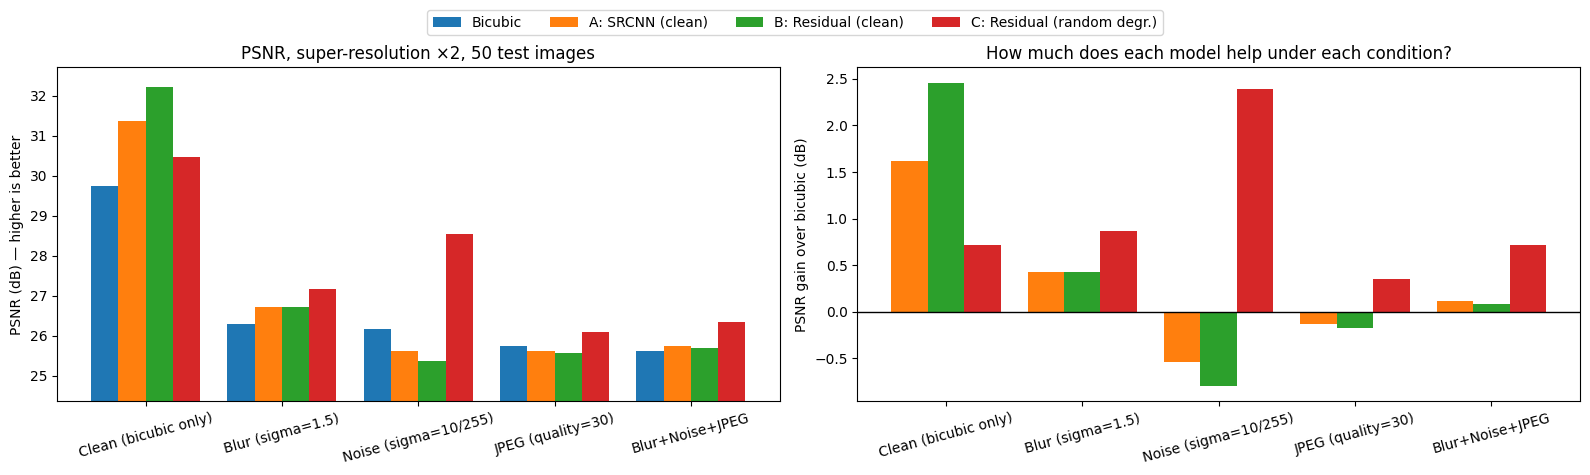

In [ ]:
### Cell 16 — Biểu đồ PSNR và mức chênh so với bicubic
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
table_psnr.plot.bar(ax=axes[0], rot=15, width=0.8, legend=False)
axes[0].set_ylabel("PSNR (dB) — higher is better"); axes[0].set_xlabel("")
axes[0].set_ylim(table_psnr.values.min() - 1, table_psnr.values.max() + 0.5)
axes[0].set_title(f"PSNR, super-resolution ×{SCALE}, {len(test_hr)} test images")

# Gain over bicubic: > 0 means the model helps, < 0 means it is WORSE than no model at all
gain = table_psnr.sub(table_psnr["Bicubic"], axis=0).drop(columns="Bicubic")
gain.plot.bar(ax=axes[1], rot=15, width=0.8, color=["C1", "C2", "C3"], legend=False)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_ylabel("PSNR gain over bicubic (dB)"); axes[1].set_xlabel("")
axes[1].set_title("How much does each model help under each condition?")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

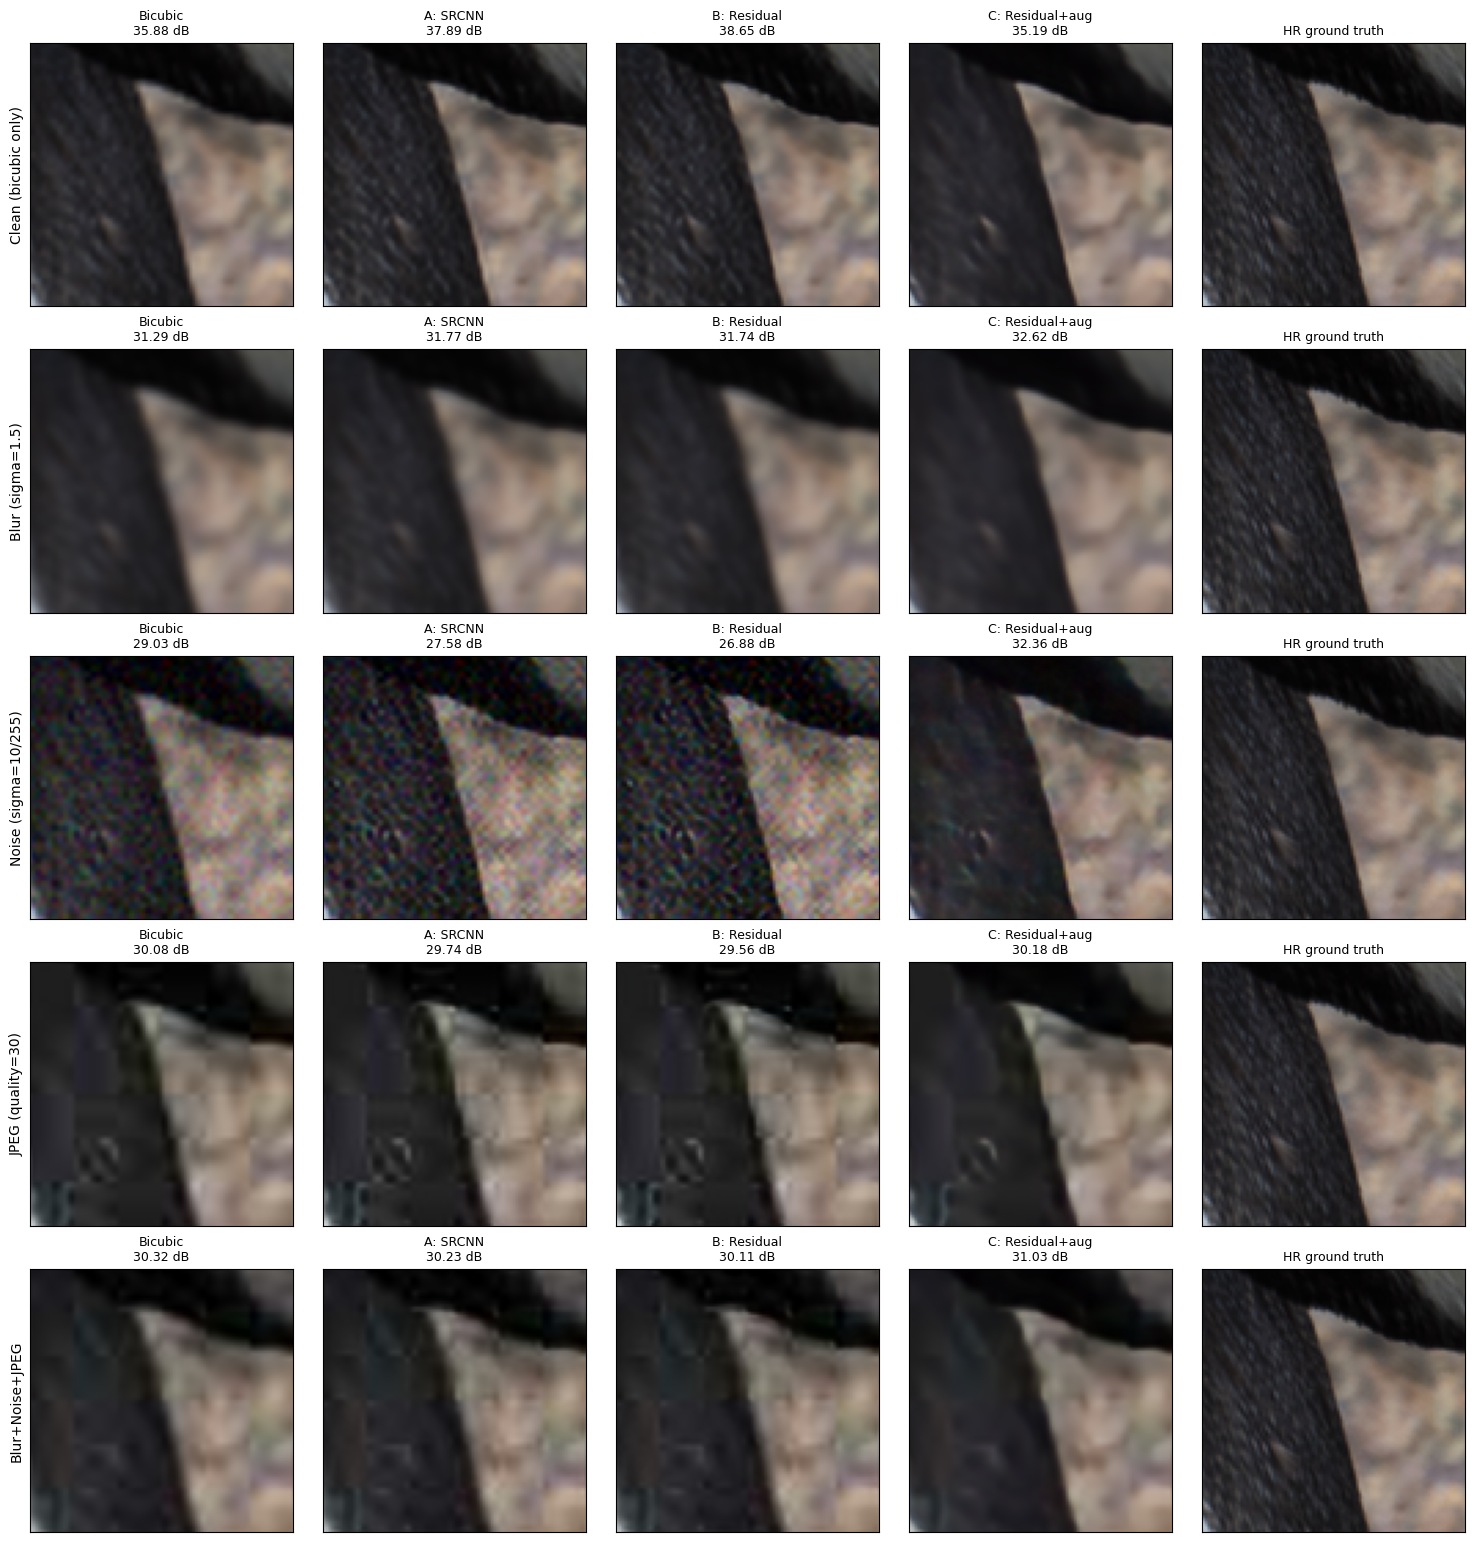

In [ ]:
### Cell 17 — So sánh bằng mắt (hàng = điều kiện test, cột = phương pháp)
IMG = 0                                      # change to look at another test image
methods = {"Bicubic": None, "A: SRCNN": model_A, "B: Residual": model_B, "C: Residual+aug": model_C}
fig, axes = plt.subplots(len(TEST_CONDITIONS), len(methods) + 1, figsize=(15, 3.1 * len(TEST_CONDITIONS)))
for r, (cond, imgs) in enumerate(test_inputs.items()):
    x = imgs[IMG:IMG + 1]
    for c, (mname, model) in enumerate(methods.items()):
        out = x[0] if model is None else np.clip(model.predict(x, verbose=0)[0], 0, 1)
        p, _ = evaluate(out[None], test_hr[IMG:IMG + 1])
        axes[r, c].imshow(out[z, z]); axes[r, c].set_title(f"{mname}\n{p:.2f} dB", fontsize=9)
    axes[r, -1].imshow(test_hr[IMG][z, z]); axes[r, -1].set_title("HR ground truth", fontsize=9)
    axes[r, 0].set_ylabel(cond, fontsize=10)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Saving Screenshot 2026-10-04 122624.png to Screenshot 2026-10-04 122624.png


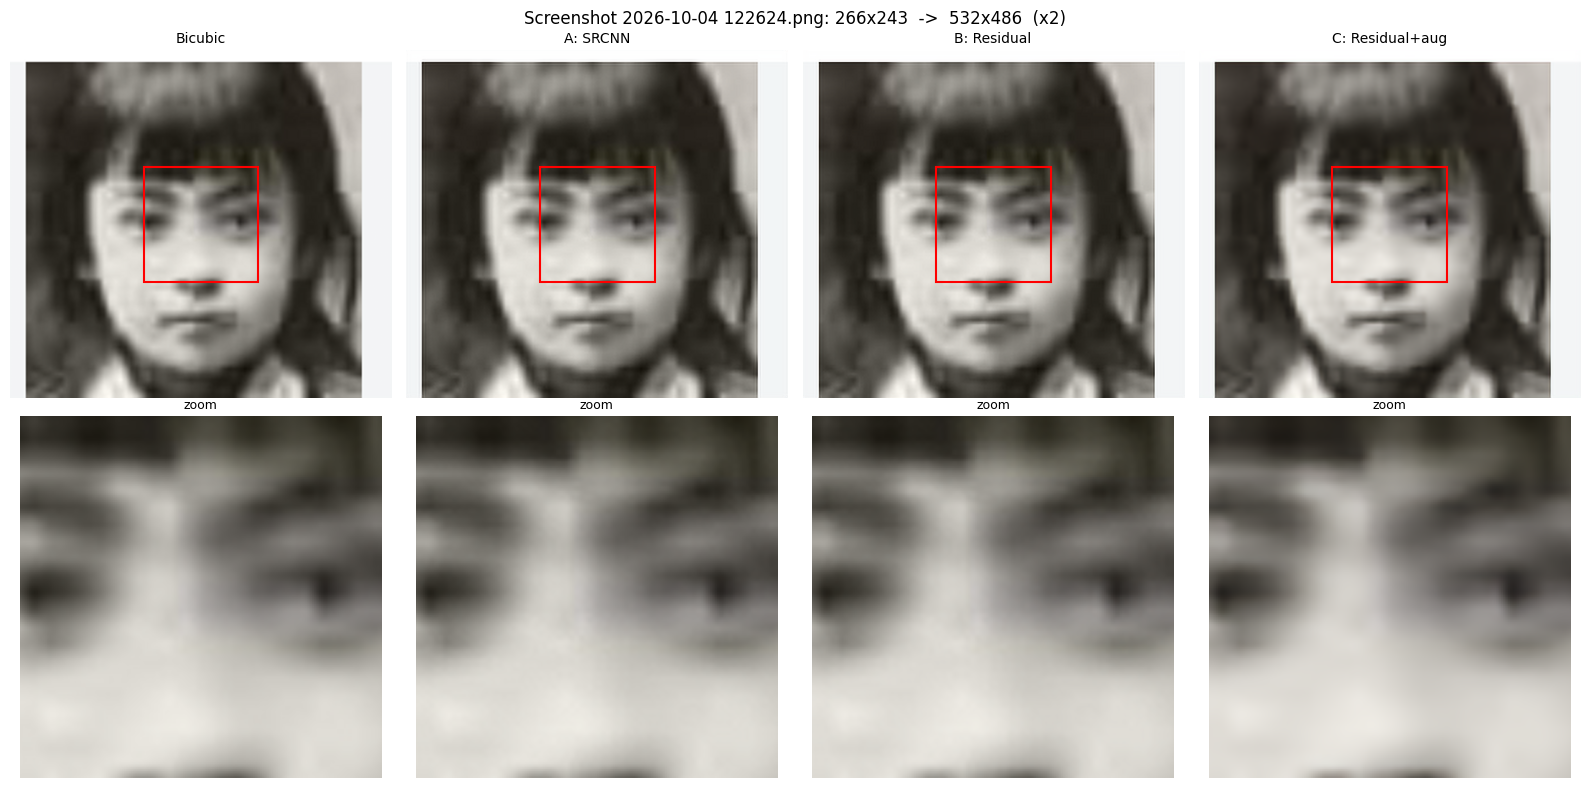

Saved: Screenshot 2026-10-04 122624_x2_bicubic.png, Screenshot 2026-10-04 122624_x2_A.png, Screenshot 2026-10-04 122624_x2_B.png, Screenshot 2026-10-04 122624_x2_C.png


In [ ]:
### cell18 test
from google.colab import files
import io

TREAT_AS_HR = False        # False: ảnh tải lên là ảnh nhỏ/xấu cần làm nét (trường hợp thực tế, không có đáp án)
                           # True : ảnh tải lên là ảnh nét; code tự làm xấu nó rồi phục hồi, có PSNR để so sánh
CONDITION = "Blur+Noise+JPEG"   # chỉ dùng khi TREAT_AS_HR = True; chọn 1 tên trong TEST_CONDITIONS
MAX_SIDE = 800             # ảnh có cạnh dài hơn sẽ được thu nhỏ trước, tránh tràn bộ nhớ GPU

def run_models(inp):
    # inp: ảnh đã phóng to bằng bicubic, [H, W, 3] trong [0, 1]
    outs = {"Bicubic": inp}
    for label, model in [("A: SRCNN", model_A), ("B: Residual", model_B), ("C: Residual+aug", model_C)]:
        outs[label] = np.clip(model.predict(inp[None], verbose=0)[0], 0.0, 1.0)
    return outs

def test_my_image(img, name):
    h, w, _ = img.shape
    if max(h, w) > MAX_SIDE:                                   # thu nhỏ ảnh quá lớn
        s = MAX_SIDE / max(h, w)
        img = np.clip(tf.image.resize(img, [int(h * s), int(w * s)], method="area").numpy(), 0.0, 1.0)
        h, w, _ = img.shape

    if TREAT_AS_HR:
        hr = img[:h - h % SCALE, :w - w % SCALE]               # cắt cho chia hết cho SCALE
        inp = degrade(tf.constant(hr), **TEST_CONDITIONS[CONDITION])[0].numpy()
        title = f"{name}: degraded with '{CONDITION}', then restored"
    else:
        hr = None
        inp = tf.clip_by_value(tf.image.resize(img, [h * SCALE, w * SCALE], method="bicubic"), 0.0, 1.0).numpy()
        title = f"{name}: {w}x{h}  ->  {w * SCALE}x{h * SCALE}  (x{SCALE})"

    outs = run_models(inp)
    panels = dict(outs)
    if hr is not None:
        panels["HR (original)"] = hr

    H, W, _ = inp.shape
    zs = min(160, H, W)                                        # vùng phóng to ở giữa ảnh
    zy, zx = (H - zs) // 2, (W - zs) // 2
    fig, axes = plt.subplots(2, len(panels), figsize=(4 * len(panels), 8))
    for c, (label, im) in enumerate(panels.items()):
        t = label
        if hr is not None and label != "HR (original)":
            t += f"\n{evaluate(im[None], hr[None])[0]:.2f} dB"
        axes[0, c].imshow(im); axes[0, c].set_title(t, fontsize=10)
        axes[0, c].add_patch(plt.Rectangle((zx, zy), zs, zs, fill=False, ec="red", lw=1.5))
        axes[1, c].imshow(im[zy:zy + zs, zx:zx + zs]); axes[1, c].set_title("zoom", fontsize=9)
    for ax in axes.ravel(): ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

    stem = os.path.splitext(name)[0]
    for label, tag in [("Bicubic", "bicubic"), ("A: SRCNN", "A"), ("B: Residual", "B"), ("C: Residual+aug", "C")]:
        Image.fromarray((outs[label] * 255).round().astype(np.uint8)).save(f"{stem}_x{SCALE}_{tag}.png")
    print("Saved:", ", ".join(f"{stem}_x{SCALE}_{t}.png" for t in ["bicubic", "A", "B", "C"]))

uploaded = files.upload()                                      # chọn 1 hoặc nhiều ảnh từ máy tính
for name, data in uploaded.items():
    img = np.asarray(Image.open(io.BytesIO(data)).convert("RGB"), dtype=np.float32) / 255.0
    test_my_image(img, name)